# Semi-Supervised Learning for Welding Quality Prediction

---

## 1. Introduction


We have a welding quality dataset with ~1600 samples.
- **Labeled data (~45%):** We know the actual mechanical properties
- **Unlabeled data (~55%):** We have all the welding parameters but NO measurements of the following features, which are our target variables

### Targets Analyzed
- **Yield Strength (MPa)** - Yield strength (~54% labeled)
- **Ultimate Tensile Strength (MPa)** - Tensile strength (~54% labeled)
- **Elongation (%)** - Ductility (~54% labeled)
- **Reduction of Area (%)** - Reduction of area (~42% labeled)
- **Charpy Impact Toughness (J)** - Toughness (~51% labeled)


**Excluded Features:**
- **Hardness (95.2% missing)** - Insufficient data
- **Microstructure features (94.2-94.6% missing)** - Too many missing values
- These columns were removed during preprocessing


### Objective

In this notebook we are going to see how we can implement a semi-supervised learning in ordered to predict the missing data. But how can we be sure that our SSL model is actually performing well ?

This is what we are trying to find out through this notebook.

### Our approach
 **Part 1: Simple Self-Training**
- Compare baseline Random Forest with simple SSL
- Use confidence-based pseudo-labeling
- Analyze improvement for each target

**Part 2: Advanced Self-Training**
- Enhanced SSL with ensemble models (XGBoost, LightGBM, RF)
- Adaptive confidence thresholds
- Sample weighting based on prediction certainty
- Diversity sampling strategy


## 2. Setup & Data Loading

### 2.1 Libraries Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df=pd.read_csv('cealnwelddata.csv')

## 3. Feature and Target Definition

### Feature Columns (40 total)
- **Chemical composition (weight%):** C, Si, Mn, S, P, Ni, Cr, Mo, V, Cu, Co, W (12)
- **Chemical composition (ppm):** O, Ti, N, Al, B, Nb, Sn, As, Sb (9)
- **Process parameters:** Current, Voltage, AC/DC, Polarity, Heat input, Interpass temp (6)
- **Post-weld treatment:** Temperature, Time (2)
- **Charpy test condition:** Temperature (1)
- **Weld type (one-hot encoded):** FCA, GMAA, GTAA, MMA, NGGMA, NGSAW, SA, SAA, ShMA, TSA (10)

### Target Variables (5)
**Mechanical properties** - These will have many missing values, which is why SSL is relevant!
- Yield strength
- Ultimate tensile strength  
- Elongation
- Reduction of Area
- Charpy impact toughness



In [ ]:
features_cols = [
    "Carbon concentration (weight%)",
    "Silicon concentration (weight%)",
    "Manganese concentration (weight%)",
    "Sulphur concentration (weight%)",
    "Phosphorus concentration (weight%)",
    "Nickel concentration (weight%)",
    "Chromium concentration (weight%)",
    "Molybdenum concentration (weight%)",
    "Vanadium concentration (weight%)",
    "Copper concentration (weight%)",
    "Cobalt concentration (weight%)",
    "Tungsten concentration (weight%)",
    "Oxygen concentration (ppm by weight)",
    "Titanium concentration (ppm by weight)",
    "Nitrogen concentration (ppm by weight)",
    "Aluminium concentration (ppm by weight)",
    "Boron concentration (ppm by weight)",
    "Niobium concentration (ppm by weight)",
    "Tin concentration (ppm by weight)",
    "Arsenic concentration (ppm by weight)",
    "Antimony concentration (ppm by weight)",
    "Current (A)",
    "Voltage (V)",
    "AC or DC",
    "Electrode polarity (positive or negative)",
    "Heat input (kJmm-1)",
    "Interpass temperature (°C)",
    "Post weld heat treatment temperature (°C)",
    "Post weld heat treatment time (hours)","Charpy temperature (°C)",
    "weld_type_FCA","weld_type_GMAA" ,"weld_type_GTAA","weld_type_MMA","weld_type_NGGMA","weld_type_NGSAW","weld_type_SA" ,"weld_type_SAA","weld_type_ShMA" ,"weld_type_TSA"
]


We seperate the Charpy column to exploit it as our first feature

In [ ]:
mechanical_cols = [
    "Yield strength (MPa)",
    "Ultimate tensile strength (MPa)",
    "Elongation (%)",
    "Reduction of Area (%)"
]

charpy_cols = [
    "Charpy impact toughness (J)"
]

In [ ]:
X = df[features_cols].copy()
y_mechanical = df[mechanical_cols].copy()
y_charpy = df[charpy_cols].copy()

# 4. Our approach

**Objective:** To empirically validate whether a Self-Supervised Learning (SSL) model effectively leverages unlabeled data to improve performance on a supervised task.

We parted from the hypothesis that if our SSL model has learned meaningful representations from both labeled and unlabeled data, it should perform better on a held-out test set than a model trained only on the limited labeled data.

##  Methodology



**Baseline Model :** Train a model using only the available labeled data. This establishes our performance baseline.

**SSL Model :** Train a model using all data (labeled + unlabeled) with a Self-Supervised Learning technique.

**Comparative Evaluation:** Compare the performance of M1 and M2 on the same labeled test set. An improvement in M2's metrics indicates that the SSL approach was successful.

## 4.1 Baseline model vs Simple SSL



For our baseline model, we split our data:
1. Separate **Labeled** vs **Unlabeled** Data
2. Split Labeled into **Train (80%)** et **Test (20%)**   
3. Return Train, Unlabeled, Test

In [ ]:
def split_4_parts(X, y, test_size=0.2, random_state=42):

    mask_labeled = y.notna()
    X_labeled = X[mask_labeled]
    y_labeled = y[mask_labeled]
    X_unlabeled = X[~mask_labeled]

    if len(X_labeled) < 20:
        return None

    # Split labeled en train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_labeled, y_labeled, test_size=test_size, random_state=random_state
    )

    return X_train, y_train, X_unlabeled, X_test, y_test


Classe SSL Simple

In [ ]:
class SimpleSelfTraining:

    def __init__(self, confidence_percentile=25, max_iterations=5):
        self.confidence_percentile = confidence_percentile
        self.max_iterations = max_iterations
        self.model = None
        self.history = []

    def fit(self, X_train, y_train, X_unlabeled):
        """Entraîne avec SSL"""
        X_current = X_train.copy()
        y_current = y_train.copy()
        X_remaining = X_unlabeled.copy()

        for iteration in range(self.max_iterations):
            # Entraîner
            model = RandomForestRegressor(n_estimators=100, max_depth=15,
                                         min_samples_split=5, random_state=42, n_jobs=-1)
            model.fit(X_current, y_current)

            if len(X_remaining) == 0:
                break

            # Prédire avec incertitude
            tree_preds = np.array([tree.predict(X_remaining) for tree in model.estimators_])
            pred_mean = tree_preds.mean(axis=0)
            pred_std = tree_preds.std(axis=0)

            # Sélectionner les plus confiants
            threshold = np.percentile(pred_std, self.confidence_percentile)
            confident_mask = pred_std <= threshold
            n_confident = confident_mask.sum()

            if n_confident == 0:
                break

            # Ajouter au training
            X_confident = X_remaining[confident_mask]
            y_confident = pd.Series(pred_mean[confident_mask], index=X_confident.index)

            X_current = pd.concat([X_current, X_confident])
            y_current = pd.concat([y_current, y_confident])
            X_remaining = X_remaining[~confident_mask]

            self.history.append({
                'iteration': iteration + 1,
                'n_train': len(X_current),
                'n_added': n_confident
            })

        # Modèle final
        self.model = RandomForestRegressor(n_estimators=100, max_depth=15,
                                          min_samples_split=5, random_state=42, n_jobs=-1)
        self.model.fit(X_current, y_current)
        return self

    def predict(self, X):
        return self.model.predict(X)


In [ ]:
def train_one_target(X, y, target_name, test_size=0.2):
    """Entraîne Baseline et SSL pour une target"""

    # Split
    result = split_4_parts(X, y, test_size)
    if result is None:
        return None

    X_train, y_train, X_unlabeled, X_test, y_test = result

    # Normaliser
    scaler = StandardScaler()
    X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns, index=X_train.index)
    X_unlabeled_sc = pd.DataFrame(scaler.transform(X_unlabeled),
                                   columns=X_unlabeled.columns, index=X_unlabeled.index)
    X_test_sc = pd.DataFrame(scaler.transform(X_test),
                            columns=X_test.columns, index=X_test.index)

    # === BASELINE ===
    model_base = RandomForestRegressor(n_estimators=100, max_depth=15,
                                       min_samples_split=5, random_state=42, n_jobs=-1)
    model_base.fit(X_train_sc, y_train)
    y_pred_base = model_base.predict(X_test_sc)

    r2_base = r2_score(y_test, y_pred_base)
    mae_base = mean_absolute_error(y_test, y_pred_base)

    # === SSL ===
    model_ssl = SimpleSelfTraining(confidence_percentile=25, max_iterations=5)
    model_ssl.fit(X_train_sc, y_train, X_unlabeled_sc)
    y_pred_ssl = model_ssl.predict(X_test_sc)

    r2_ssl = r2_score(y_test, y_pred_ssl)
    mae_ssl = mean_absolute_error(y_test, y_pred_ssl)

    # Résultats
    return {
        'target': target_name,
        'n_train': len(X_train),
        'n_unlabeled': len(X_unlabeled),
        'n_test': len(X_test),
        'r2_base': r2_base,
        'mae_base': mae_base,
        'r2_ssl': r2_ssl,
        'mae_ssl': mae_ssl,
        'improvement_r2': r2_ssl - r2_base,
        'improvement_r2_pct': ((r2_ssl - r2_base) / abs(r2_base) * 100) if r2_base != 0 else 0,
        'improvement_mae': mae_base - mae_ssl,
        'improvement_mae_pct': ((mae_base - mae_ssl) / mae_base * 100) if mae_base != 0 else 0,
        'ssl_history': model_ssl.history,
        'model_base': model_base,
        'model_ssl': model_ssl.model,
        'scaler': scaler,
        'y_test': y_test,
        'y_pred_base': y_pred_base,
        'y_pred_ssl': y_pred_ssl
    }


Entraîner Toutes les Targets

In [ ]:
print("\n" + "="*70)
print("ENTRAÎNEMENT : BASELINE vs SSL")
print("="*70)

all_results = {}

for col in mechanical_cols + charpy_cols:
    print(f"\n>>> {col}")
    result = train_one_target(X, df[col], col, test_size=0.2)

    if result is not None:
        all_results[col] = result
        print(f"    Train: {result['n_train']}, Unlabeled: {result['n_unlabeled']}, Test: {result['n_test']}")
        print(f"    Baseline R²: {result['r2_base']:.4f}, MAE: {result['mae_base']:.2f}")
        print(f"    SSL R²:      {result['r2_ssl']:.4f}, MAE: {result['mae_ssl']:.2f}")
        print(f"    Δ R²: {result['improvement_r2']:+.4f} ({result['improvement_r2_pct']:+.2f}%)")


print(f"\n✓ Entraînement terminé pour {len(all_results)} targets")


ENTRAÎNEMENT : BASELINE vs SSL

>>> Yield strength (MPa)
    Train: 613, Unlabeled: 872, Test: 154
    Baseline R²: 0.7890, MAE: 28.41
    SSL R²:      0.7482, MAE: 30.92
    Δ R²: -0.0408 (-5.17%)

>>> Ultimate tensile strength (MPa)
    Train: 590, Unlabeled: 901, Test: 148
    Baseline R²: 0.8051, MAE: 28.74
    SSL R²:      0.7968, MAE: 29.50
    Δ R²: -0.0083 (-1.03%)

>>> Elongation (%)
    Train: 549, Unlabeled: 952, Test: 138
    Baseline R²: 0.6738, MAE: 1.92
    SSL R²:      0.6789, MAE: 1.99
    Δ R²: +0.0051 (+0.76%)

>>> Reduction of Area (%)
    Train: 553, Unlabeled: 947, Test: 139
    Baseline R²: 0.6599, MAE: 2.22
    SSL R²:      0.6561, MAE: 2.28
    Δ R²: -0.0039 (-0.58%)

>>> Charpy impact toughness (J)
    Train: 703, Unlabeled: 760, Test: 176
    Baseline R²: 0.8212, MAE: 16.41
    SSL R²:      0.8074, MAE: 17.11
    Δ R²: -0.0138 (-1.68%)

✓ Entraînement terminé pour 5 targets


In [ ]:
comparison_data = []

for target, res in all_results.items():
    comparison_data.append({
        'Target': target.split('(')[0].strip(),
        'N_train': res['n_train'],
        'N_unlabeled': res['n_unlabeled'],
        'N_test': res['n_test'],
        'R²_Baseline': res['r2_base'],
        'R²_SSL': res['r2_ssl'],
        'ΔR²': res['improvement_r2'],
        'ΔR²_%': res['improvement_r2_pct'],
        'MAE_Baseline': res['mae_base'],
        'MAE_SSL': res['mae_ssl'],
        'ΔMAE_%': res['improvement_mae_pct']
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("TABLEAU RÉCAPITULATIF")
print("="*100)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print("="*100)

print(f"\n📊 MOYENNES:")
print(f"  Amélioration R²:  {comparison_df['ΔR²_%'].mean():+.2f}%")
print(f"  Amélioration MAE: {comparison_df['ΔMAE_%'].mean():+.2f}%")
print(f"  Targets améliorées: {(comparison_df['ΔR²'] > 0).sum()}/{len(comparison_df)}")


TABLEAU RÉCAPITULATIF
                   Target  N_train  N_unlabeled  N_test  R²_Baseline  R²_SSL   ΔR²  ΔR²_%  MAE_Baseline  MAE_SSL  ΔMAE_%
           Yield strength      613          872     154         0.79    0.75 -0.04  -5.17         28.41    30.92   -8.84
Ultimate tensile strength      590          901     148         0.81    0.80 -0.01  -1.03         28.74    29.50   -2.64
               Elongation      549          952     138         0.67    0.68  0.01   0.76          1.92     1.99   -3.33
        Reduction of Area      553          947     139         0.66    0.66 -0.00  -0.58          2.22     2.28   -2.63
  Charpy impact toughness      703          760     176         0.82    0.81 -0.01  -1.68         16.41    17.11   -4.27

📊 MOYENNES:
  Amélioration R²:  -1.54%
  Amélioration MAE: -4.34%
  Targets améliorées: 1/5


Looking at the actual output, we see **mostly negative improvements**, which means:
- Simple SSL with Random Forest isnot really improving performance
- Possible reasons:
  1. Pseudo-labels are adding noise rather than signal
  2. Confidence threshold (25th percentile) may be too lenient
  3. Random Forest baseline is already quite good
  4. Unlabeled data distribution may differ from labeled

**Key Finding:** Only 1 out of 5 targets showed improvement with simple SSL!

This motivates the **Advanced SSL** approach in Part 2.

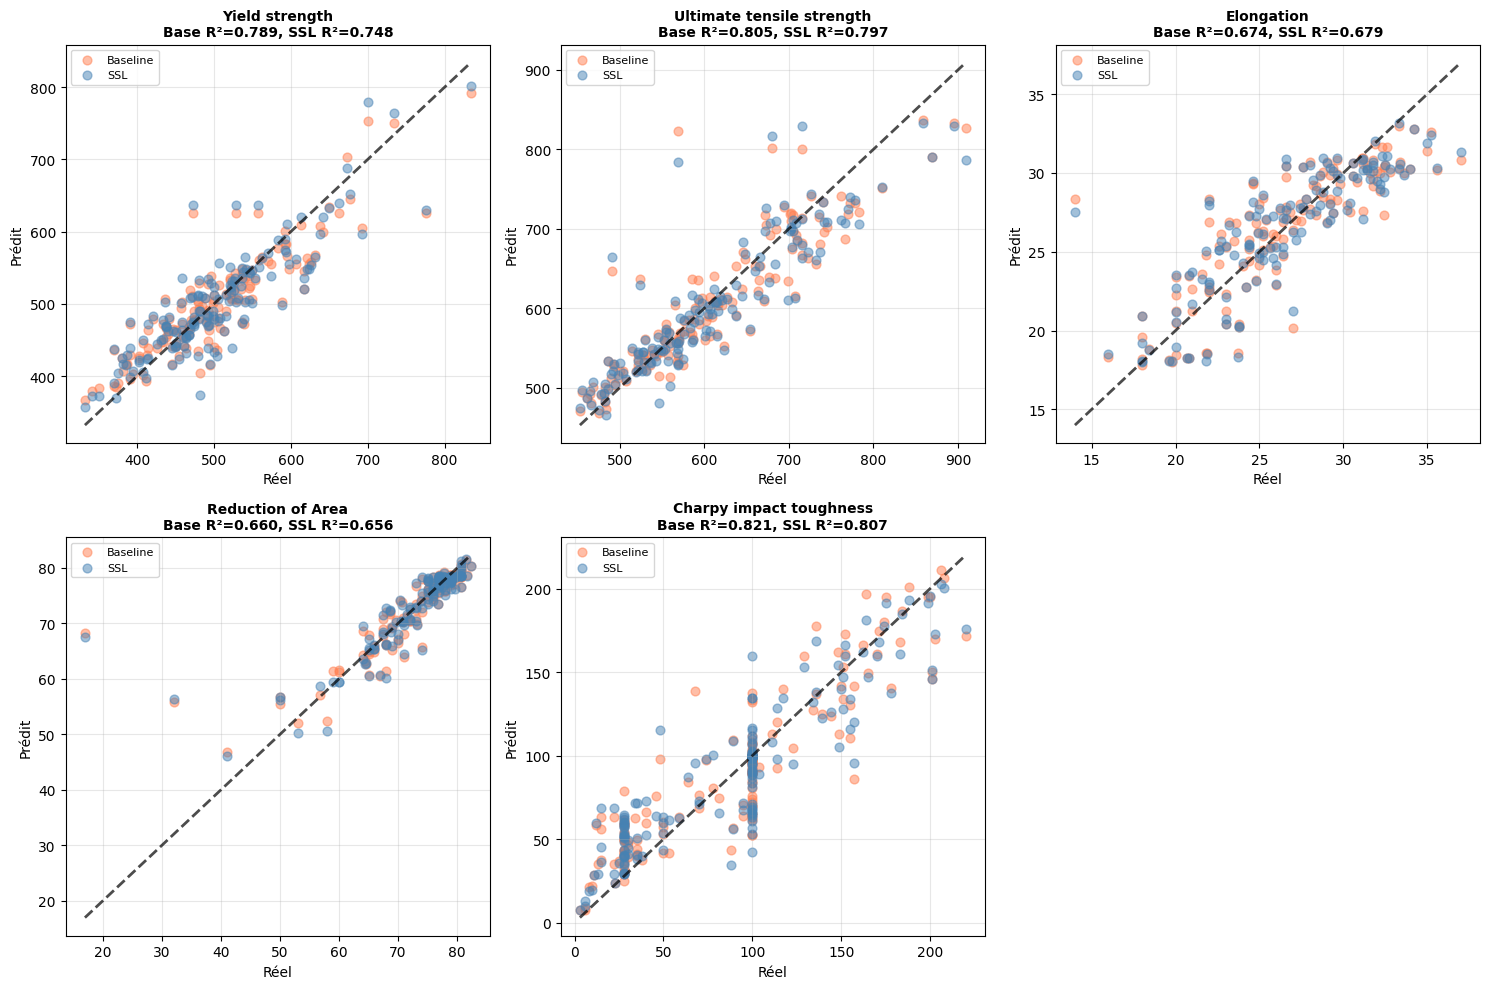

In [ ]:
n = len(all_results)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes = axes.flatten() if n > 1 else [axes]

for idx, (target, res) in enumerate(all_results.items()):
    ax = axes[idx]

    y_test = res['y_test']
    y_pred_base = res['y_pred_base']
    y_pred_ssl = res['y_pred_ssl']

    # Scatter
    ax.scatter(y_test, y_pred_base, alpha=0.5, s=40, label='Baseline', color='coral')
    ax.scatter(y_test, y_pred_ssl, alpha=0.5, s=40, label='SSL', color='steelblue')

    # Ligne parfaite
    min_val = min(y_test.min(), y_pred_base.min(), y_pred_ssl.min())
    max_val = max(y_test.max(), y_pred_base.max(), y_pred_ssl.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7)

    short_name = target.split('(')[0].strip()
    ax.set_title(f"{short_name}\nBase R²={res['r2_base']:.3f}, SSL R²={res['r2_ssl']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Réel')
    ax.set_ylabel('Prédit')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Cacher axes vides
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Let's see how our training data improves during SSL

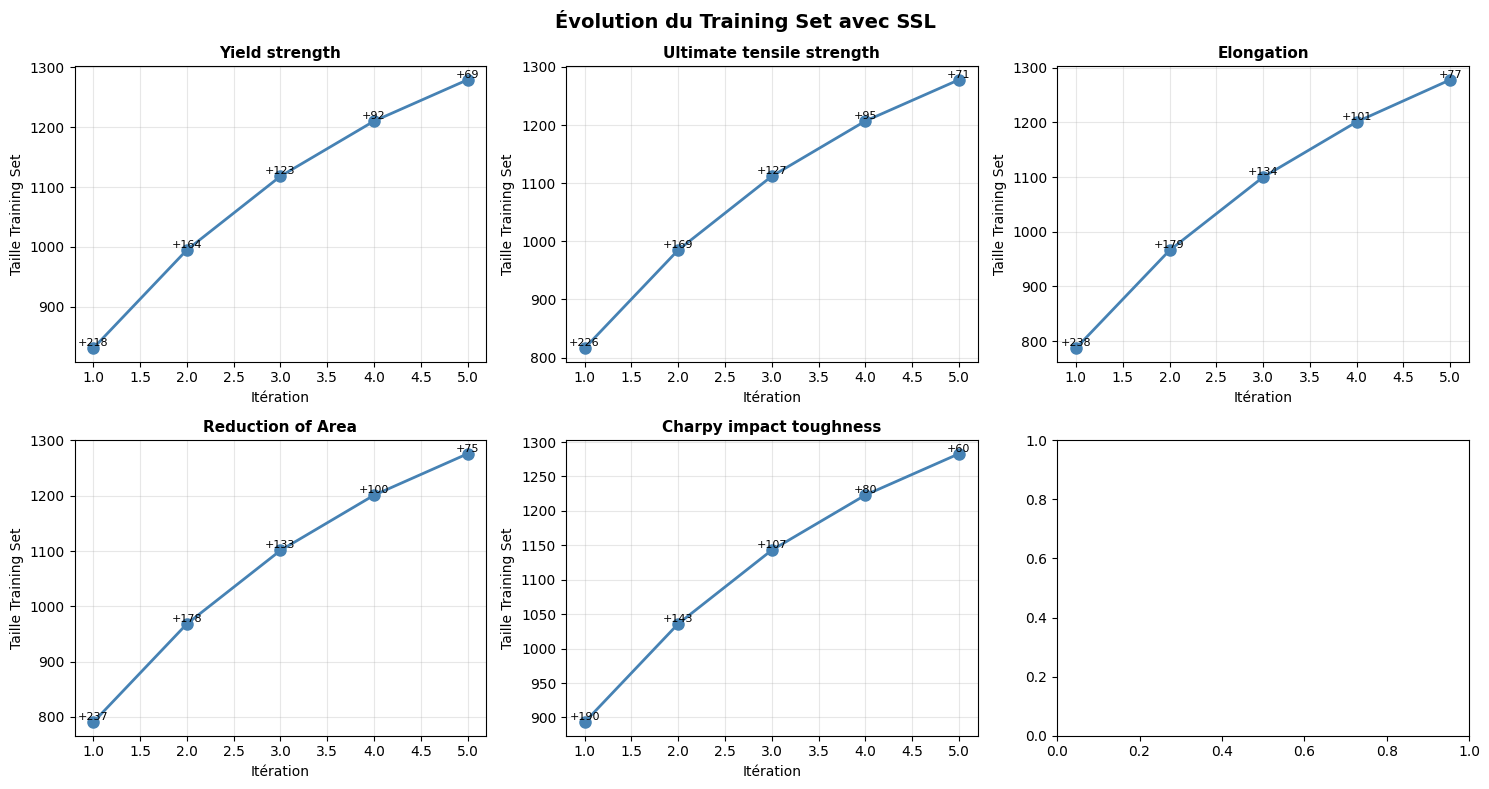

In [ ]:

targets_to_show = list(all_results.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, target in enumerate(targets_to_show):
    if target not in all_results:
        continue

    history = all_results[target]['ssl_history']
    if not history:
        continue

    ax = axes[idx]
    iterations = [h['iteration'] for h in history]
    n_trains = [h['n_train'] for h in history]
    n_added = [h['n_added'] for h in history]

    # Ligne d'évolution
    ax.plot(iterations, n_trains, marker='o', linewidth=2, markersize=8, color='steelblue')
    ax.set_title(target.split('(')[0].strip(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Itération')
    ax.set_ylabel('Taille Training Set')
    ax.grid(True, alpha=0.3)

    # Annotations
    for i, (iter, n_train, n_add) in enumerate(zip(iterations, n_trains, n_added)):
        ax.text(iter, n_train, f'+{n_add}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Évolution du Training Set avec SSL', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 Advanced SSL

In order to achieve better results, we implemented an advanced SSL with:

**1. Better Base Models**
**XGBoost**,  **LightGBM**: Fast gradient boosting, **Ensemble**: Stack multiple models (XGB + LGB + RF)

**2. Adaptive Confidence Threshold**
- Starts strict (10th percentile)n thus few samples but more confident.
- Gradually relaxes (up to 50th percentile) so we introduce more samples as model improves, this helps us prevent early error propagation

**3. Sample Weighting**
- Pseudo-labels weighted by confidence
- High certainty → Weight ≈ 1.0 (like real labels)
- Low certainty → Weight ≈ 0.1 (less influence)
- Model learns: "trust confident predictions more"



In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')


In [ ]:
class AdvancedSelfTraining:
    """
    Self-Training Avancé avec:
    - Ensemble de modèles (XGBoost, LightGBM, RF)
    - Score de confiance adaptatif
    - Pondération dynamique des pseudo-labels
    - Stratégies de sélection intelligentes
    """

    def __init__(self,
                 model_type='ensemble',  # 'xgboost', 'lightgbm', 'rf', 'ensemble'
                 initial_confidence_percentile=25,
                 adaptive_threshold=True,
                 use_weights=True,
                 max_iterations=10,
                 min_improvement=0.001,
                 verbose=True):

        self.model_type = model_type
        self.initial_confidence_percentile = initial_confidence_percentile
        self.adaptive_threshold = adaptive_threshold
        self.use_weights = use_weights
        self.max_iterations = max_iterations
        self.min_improvement = min_improvement
        self.verbose = verbose

        self.model = None
        self.history = []
        self.confidence_threshold_history = []

    def _create_base_model(self):
        """Crée le modèle de base selon le type"""
        if self.model_type == 'xgboost':
            return xgb.XGBRegressor(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                tree_method='hist'
            )

        elif self.model_type == 'lightgbm':
            return lgb.LGBMRegressor(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                verbose=-1
            )

        elif self.model_type == 'rf':
            return RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                random_state=42,
                n_jobs=-1
            )

        elif self.model_type == 'ensemble':
            # Ensemble de plusieurs modèles
            base_models = [
                ('xgb', xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                                        random_state=42, n_jobs=-1, tree_method='hist')),
                ('lgb', lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                                         random_state=42, n_jobs=-1, verbose=-1)),
                ('rf', RandomForestRegressor(n_estimators=100, max_depth=12,
                                            random_state=42, n_jobs=-1))
            ]
            return StackingRegressor(
                estimators=base_models,
                final_estimator=Ridge(alpha=1.0),
                n_jobs=-1
            )

    def _compute_uncertainty(self, X, model, method='ensemble_variance'):
        """
        Calcule l'incertitude des prédictions

        Méthodes:
        - ensemble_variance: variance entre les arbres (RF) ou estimateurs
        - prediction_interval: intervalle de prédiction
        - ensemble_diversity: diversité des prédictions
        """
        if method == 'ensemble_variance' and hasattr(model, 'estimators_'):
            # Random Forest ou Gradient Boosting
            predictions = np.array([est.predict(X) for est in model.estimators_])
            uncertainty = predictions.std(axis=0)

        elif method == 'ensemble_variance' and isinstance(model, StackingRegressor):
            # Stacking: variance entre modèles de base
            predictions = []
            for name, est in model.estimators_:
                predictions.append(est.predict(X))
            predictions = np.array(predictions)
            uncertainty = predictions.std(axis=0)

        elif method == 'prediction_interval':
            # Intervalle de confiance basé sur résidus
            pred = model.predict(X)
            # Approximation simple
            uncertainty = np.abs(pred) * 0.1  # 10% du signal

        else:
            # Par défaut: prédiction simple sans incertitude
            pred = model.predict(X)
            uncertainty = np.ones(len(pred))

        return uncertainty

    def _adaptive_confidence_threshold(self, iteration, initial_percentile):
        """
        Seuil de confiance adaptatif:
        - Commence strict (peu de données ajoutées)
        - S'assouplit progressivement (plus de données ajoutées)
        """
        if not self.adaptive_threshold:
            return initial_percentile

        # Stratégie: commencer strict, puis assouplir
        # Itération 1: 15%, Itération 5: 35%, Itération 10: 50%
        min_percentile = 10
        max_percentile = 50

        progress = iteration / self.max_iterations
        current_percentile = min_percentile + (max_percentile - min_percentile) * progress

        return current_percentile

    def _compute_sample_weights(self, uncertainties):
        """
        Calcule les poids des échantillons selon leur certitude

        Principe: échantillons plus certains = poids plus élevés
        """
        # Inverser l'incertitude: faible incertitude = poids élevé
        certainties = 1.0 / (uncertainties + 1e-6)

        # Normaliser entre 0.1 et 1.0
        weights = (certainties - certainties.min()) / (certainties.max() - certainties.min() + 1e-6)
        weights = 0.1 + 0.9 * weights  # Entre 0.1 et 1.0

        return weights

    def _diversity_sampling(self, X_unlabeled, predictions, uncertainties, n_samples):
        """
        Sélection diversifiée: éviter de prendre des échantillons trop similaires
        """
        selected_indices = []
        remaining_indices = list(range(len(X_unlabeled)))

        # Commencer par le plus certain
        first_idx = np.argmin(uncertainties)
        selected_indices.append(first_idx)
        remaining_indices.remove(first_idx)

        # Sélectionner les suivants par distance + certitude
        while len(selected_indices) < n_samples and len(remaining_indices) > 0:
            # Distance aux déjà sélectionnés
            X_selected = X_unlabeled.iloc[selected_indices]

            best_score = -np.inf
            best_idx = None

            for idx in remaining_indices:
                X_candidate = X_unlabeled.iloc[idx:idx+1]

                # Distance minimale aux sélectionnés
                distances = np.sqrt(((X_selected - X_candidate.values) ** 2).sum(axis=1))
                min_distance = distances.min()

                # Score = certitude * distance (favorise diversité + certitude)
                certainty = 1.0 / (uncertainties[idx] + 1e-6)
                score = certainty * min_distance

                if score > best_score:
                    best_score = score
                    best_idx = idx

            if best_idx is not None:
                selected_indices.append(best_idx)
                remaining_indices.remove(best_idx)

        return np.array(selected_indices)

    def fit(self, X_train, y_train, X_unlabeled):
        """Entraîne avec Self-Training avancé"""

        X_current = X_train.copy()
        y_current = y_train.copy()
        weights_current = np.ones(len(y_current))  # Poids initiaux = 1.0
        X_remaining = X_unlabeled.copy()

        prev_score = -np.inf

        for iteration in range(self.max_iterations):

            # 1. Entraîner le modèle
            model = self._create_base_model()

            if self.use_weights:
                model.fit(X_current, y_current, sample_weight=weights_current)
            else:
                model.fit(X_current, y_current)

            # Score sur données labellisées originales (validation interne)
            score = model.score(X_train, y_train)

            if len(X_remaining) == 0:
                if self.verbose:
                    print(f"  Iter {iteration + 1}: Plus de données unlabeled")
                break

            # 2. Prédire sur unlabeled avec incertitude
            predictions = model.predict(X_remaining)
            uncertainties = self._compute_uncertainty(X_remaining, model, method='ensemble_variance')

            # 3. Seuil adaptatif
            current_percentile = self._adaptive_confidence_threshold(
                iteration + 1, self.initial_confidence_percentile
            )
            threshold = np.percentile(uncertainties, current_percentile)

            # 4. Sélectionner les échantillons confiants
            confident_mask = uncertainties <= threshold
            n_confident = confident_mask.sum()

            if n_confident == 0:
                if self.verbose:
                    print(f"  Iter {iteration + 1}: Aucune prédiction confiante (seuil={threshold:.4f})")
                break

            # 5. Diversité dans la sélection (optionnel)
            if n_confident > 50:  # Si beaucoup de candidats, diversifier
                confident_indices = np.where(confident_mask)[0]
                n_to_select = min(n_confident, int(len(X_remaining) * 0.15))  # Max 15% par iter

                selected_indices = self._diversity_sampling(
                    X_remaining.iloc[confident_indices],
                    predictions[confident_indices],
                    uncertainties[confident_indices],
                    n_to_select
                )

                # Mapper aux indices originaux
                final_mask = np.zeros(len(X_remaining), dtype=bool)
                final_mask[confident_indices[selected_indices]] = True
                confident_mask = final_mask
                n_confident = final_mask.sum()

            # 6. Calculer les poids pour les nouveaux échantillons
            if self.use_weights:
                new_weights = self._compute_sample_weights(uncertainties[confident_mask])
            else:
                new_weights = np.ones(n_confident)

            # 7. Ajouter au training set
            X_confident = X_remaining[confident_mask]
            y_confident = pd.Series(predictions[confident_mask], index=X_confident.index)

            X_current = pd.concat([X_current, X_confident])
            y_current = pd.concat([y_current, y_confident])
            weights_current = np.concatenate([weights_current, new_weights])

            # Retirer du unlabeled
            X_remaining = X_remaining[~confident_mask]

            # 8. Statistiques
            avg_uncertainty = uncertainties[confident_mask].mean()
            avg_weight = new_weights.mean()

            self.history.append({
                'iteration': iteration + 1,
                'n_train': len(X_current),
                'n_added': n_confident,
                'n_remaining': len(X_remaining),
                'threshold': threshold,
                'percentile': current_percentile,
                'avg_uncertainty': avg_uncertainty,
                'avg_weight': avg_weight,
                'score': score
            })

            self.confidence_threshold_history.append(threshold)

            if self.verbose:
                print(f"  Iter {iteration + 1}: +{n_confident:3d} samples "
                      f"(train={len(X_current):4d}, remain={len(X_remaining):4d}, "
                      f"unc={avg_uncertainty:.4f}, weight={avg_weight:.3f}, "
                      f"score={score:.4f})")

            # 9. Arrêt si amélioration insuffisante
            if score - prev_score < self.min_improvement:
                if self.verbose:
                    print(f"  Iter {iteration + 1}: Amélioration insuffisante, arrêt")
                break

            prev_score = score

        # 10. Modèle final
        self.model = self._create_base_model()
        if self.use_weights:
            self.model.fit(X_current, y_current, sample_weight=weights_current)
        else:
            self.model.fit(X_current, y_current)

        if self.verbose:
            print(f"  ✓ Training final: {len(X_current)} samples")

        return self

    def predict(self, X):
        """Prédiction"""
        return self.model.predict(X)

    def get_feature_importance(self):
      if hasattr(self.model, 'feature_importances_'):
          return self.model.feature_importances_

      elif isinstance(self.model, StackingRegressor):
          importances = []

          # Vérifie le bon attribut selon la version de sklearn
          estimators = getattr(self.model, "estimators_", None)
          if estimators is None or len(estimators) == 0:
              estimators = [est for _, est in self.model.estimators]

          for est in estimators:
              if hasattr(est, "feature_importances_"):
                  importances.append(est.feature_importances_)

          return np.mean(importances, axis=0) if importances else None

      return None


In [ ]:
def train_one_target_advanced(X, y, target_name,
                             model_type='ensemble',
                             test_size=0.2,
                             confidence_percentile=25,
                             adaptive_threshold=True,
                             use_weights=True,
                             max_iterations=10):
    """Entraîne avec SSL avancé"""

    # Split
    result = split_4_parts(X, y, test_size)
    if result is None:
        return None

    X_train, y_train, X_unlabeled, X_test, y_test = result

    # Normaliser
    scaler = StandardScaler()
    X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns, index=X_train.index)
    X_unlabeled_sc = pd.DataFrame(scaler.transform(X_unlabeled),
                                   columns=X_unlabeled.columns, index=X_unlabeled.index)
    X_test_sc = pd.DataFrame(scaler.transform(X_test),
                            columns=X_test.columns, index=X_test.index)

    # === BASELINE ===
    if model_type == 'ensemble':
        base_models = [
            ('xgb', xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                                    random_state=42, n_jobs=-1, tree_method='hist')),
            ('lgb', lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.05,
                                     random_state=42, n_jobs=-1, verbose=-1)),
            ('rf', RandomForestRegressor(n_estimators=100, max_depth=12,
                                        random_state=42, n_jobs=-1))
        ]
        model_base = StackingRegressor(estimators=base_models,
                                      final_estimator=Ridge(alpha=1.0), n_jobs=-1)
    elif model_type == 'xgboost':
        model_base = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                                     random_state=42, n_jobs=-1, tree_method='hist')
    elif model_type == 'lightgbm':
        model_base = lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                                      random_state=42, n_jobs=-1, verbose=-1)
    else:
        model_base = RandomForestRegressor(n_estimators=200, max_depth=15,
                                          random_state=42, n_jobs=-1)

    model_base.fit(X_train_sc, y_train)
    y_pred_base = model_base.predict(X_test_sc)

    r2_base = r2_score(y_test, y_pred_base)
    mae_base = mean_absolute_error(y_test, y_pred_base)

    # === SSL AVANCÉ ===
    model_ssl = AdvancedSelfTraining(
        model_type=model_type,
        initial_confidence_percentile=confidence_percentile,
        adaptive_threshold=adaptive_threshold,
        use_weights=use_weights,
        max_iterations=max_iterations,
        verbose=False
    )

    model_ssl.fit(X_train_sc, y_train, X_unlabeled_sc)
    y_pred_ssl = model_ssl.predict(X_test_sc)

    r2_ssl = r2_score(y_test, y_pred_ssl)
    mae_ssl = mean_absolute_error(y_test, y_pred_ssl)

    # Résultats
    return {
        'target': target_name,
        'n_train': len(X_train),
        'n_unlabeled': len(X_unlabeled),
        'n_test': len(X_test),
        'r2_base': r2_base,
        'mae_base': mae_base,
        'r2_ssl': r2_ssl,
        'mae_ssl': mae_ssl,
        'improvement_r2': r2_ssl - r2_base,
        'improvement_r2_pct': ((r2_ssl - r2_base) / abs(r2_base) * 100) if r2_base != 0 else 0,
        'improvement_mae': mae_base - mae_ssl,
        'improvement_mae_pct': ((mae_base - mae_ssl) / mae_base * 100) if mae_base != 0 else 0,
        'ssl_history': model_ssl.history,
        'model_base': model_base,
        'model_ssl': model_ssl.model,
        'scaler': scaler,
        'y_test': y_test,
        'y_pred_base': y_pred_base,
        'y_pred_ssl': y_pred_ssl,
        'feature_importance': model_ssl.get_feature_importance()
    }


✓ Fonction d'entraînement avancée définie


In [ ]:
print("\n" + "="*70)
print("ENTRAÎNEMENT AVANCÉ : Ensemble SSL avec Poids Adaptatifs")
print("="*70)

all_results_advanced = {}

for col in mechanical_cols + charpy_cols:
    print(f"\n>>> {col}")

    result = train_one_target_advanced(
        X, df[col], col,
        model_type='xgboost',  # 'ensemble', 'xgboost', 'lightgbm', 'rf'
        test_size=0.2,
        confidence_percentile=10,  # Commence strict
        adaptive_threshold=True,   # Seuil adaptatif
        use_weights=True,          # Pondération
        max_iterations=10
    )

    if result is not None:
        all_results_advanced[col] = result
        print(f"    Baseline R²: {result['r2_base']:.4f}, MAE: {result['mae_base']:.2f}")
        print(f"    SSL R²:      {result['r2_ssl']:.4f}, MAE: {result['mae_ssl']:.2f}")
        print(f"    Δ R²: {result['improvement_r2']:+.4f} ({result['improvement_r2_pct']:+.2f}%)")
        print(f"    Iterations: {len(result['ssl_history'])}")




ENTRAÎNEMENT AVANCÉ : Ensemble SSL avec Poids Adaptatifs

>>> Yield strength (MPa)
    Baseline R²: 0.8618, MAE: 23.84
    SSL R²:      0.8625, MAE: 23.70
    Δ R²: +0.0008 (+0.09%)
    Iterations: 2

>>> Ultimate tensile strength (MPa)
    Baseline R²: 0.8573, MAE: 23.74
    SSL R²:      0.8741, MAE: 22.36
    Δ R²: +0.0168 (+1.96%)
    Iterations: 2

>>> Elongation (%)
    Baseline R²: 0.6452, MAE: 2.00
    SSL R²:      0.6787, MAE: 1.90
    Δ R²: +0.0335 (+5.20%)
    Iterations: 2

>>> Reduction of Area (%)
    Baseline R²: 0.6230, MAE: 2.33
    SSL R²:      0.6359, MAE: 2.22
    Δ R²: +0.0130 (+2.08%)
    Iterations: 2

>>> Charpy impact toughness (J)
    Baseline R²: 0.8559, MAE: 13.91
    SSL R²:      0.8713, MAE: 13.41
    Δ R²: +0.0154 (+1.80%)
    Iterations: 2

✓ 5 targets entraînées


16min d'entrainement !

In [ ]:
comparison_advanced = []

for target, res in all_results_advanced.items():
    comparison_advanced.append({
        'Target': target.split('(')[0].strip(),
        'N_train': res['n_train'],
        'N_unlabeled': res['n_unlabeled'],
        'R²_Base': res['r2_base'],
        'R²_SSL': res['r2_ssl'],
        'ΔR²_%': res['improvement_r2_pct'],
        'MAE_Base': res['mae_base'],
        'MAE_SSL': res['mae_ssl'],
        'ΔMAE_%': res['improvement_mae_pct'],
        'Iterations': len(res['ssl_history'])
    })

comp_adv_df = pd.DataFrame(comparison_advanced)

print("\n" + "="*100)
print("RÉSULTATS : SSL AVANCÉ (Ensemble + Poids Adaptatifs)")
print("="*100)
print(comp_adv_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print("="*100)

print(f"\n📊 STATISTIQUES:")
print(f"  Amélioration moyenne R²:  {comp_adv_df['ΔR²_%'].mean():+.2f}%")
print(f"  Amélioration moyenne MAE: {comp_adv_df['ΔMAE_%'].mean():+.2f}%")
print(f"  Targets améliorées: {(comp_adv_df['ΔR²_%'] > 0).sum()}/{len(comp_adv_df)}")


RÉSULTATS : SSL AVANCÉ (Ensemble + Poids Adaptatifs)
                   Target  N_train  N_unlabeled  R²_Base  R²_SSL  ΔR²_%  MAE_Base  MAE_SSL  ΔMAE_%  Iterations
           Yield strength      613          872     0.86    0.86   0.09     23.84    23.70    0.58           2
Ultimate tensile strength      590          901     0.86    0.87   1.96     23.74    22.36    5.85           2
               Elongation      549          952     0.65    0.68   5.20      2.00     1.90    5.14           2
        Reduction of Area      553          947     0.62    0.64   2.08      2.33     2.22    5.02           2
  Charpy impact toughness      703          760     0.86    0.87   1.80     13.91    13.41    3.60           2

📊 STATISTIQUES:
  Amélioration moyenne R²:  +2.23%
  Amélioration moyenne MAE: +4.04%
  Targets améliorées: 5/5



As we can see **All 5 targets** now show positive improvements! The average improvement: **+2.23%** (vs -1.54% for simple SSL) and the MAE also improved: **+4.04%** better


Analyser l'importance des features pour quelques targets

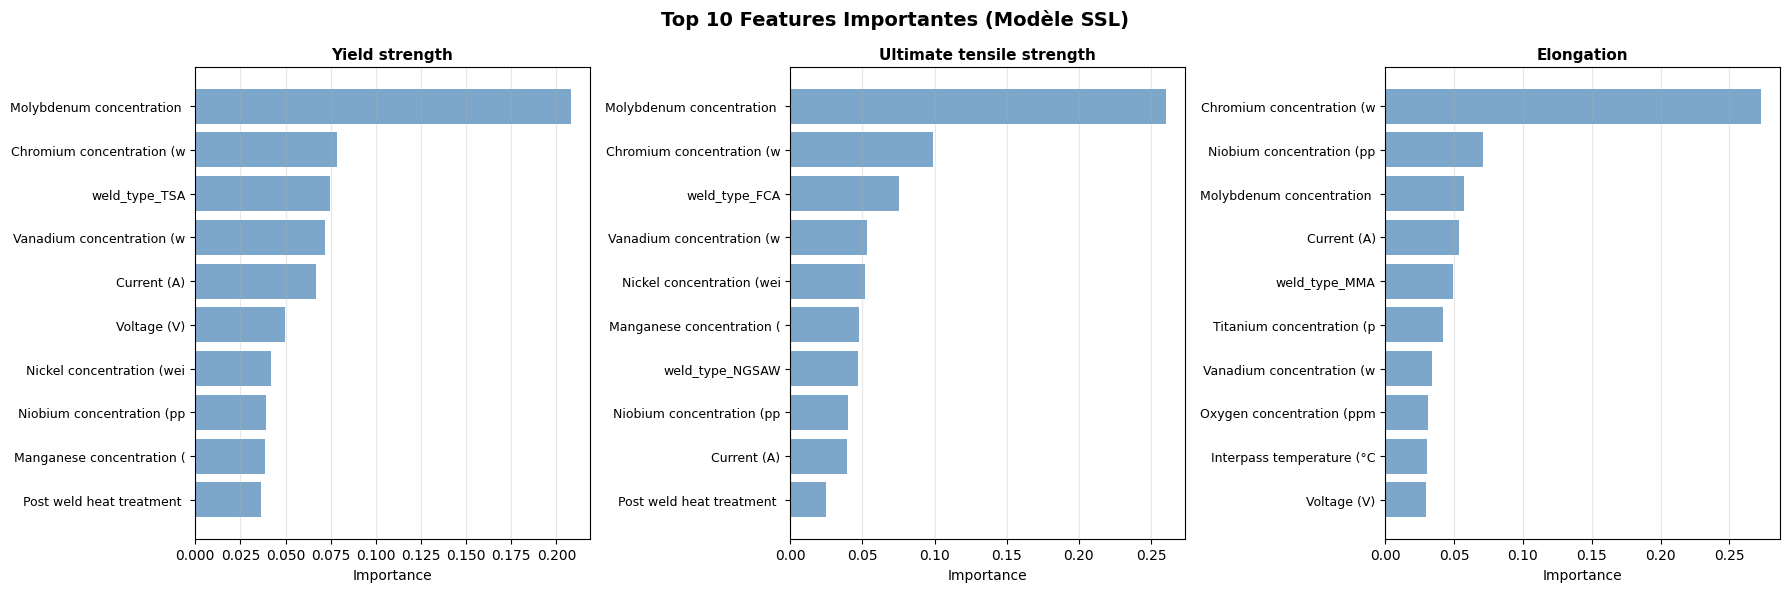

In [ ]:

targets_to_analyze = list(all_results_advanced.keys())[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, target in enumerate(targets_to_analyze):
    importance = all_results_advanced[target]['feature_importance']

    if importance is not None:
        # Top 10 features
        top_indices = np.argsort(importance)[-10:][::-1]
        top_features = [X.columns[i] for i in top_indices]
        top_scores = importance[top_indices]

        ax = axes[idx]
        y_pos = np.arange(len(top_features))
        ax.barh(y_pos, top_scores, color='steelblue', alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f[:25] for f in top_features], fontsize=9)
        ax.set_xlabel('Importance')
        ax.set_title(f'{target.split("(")[0].strip()}', fontweight='bold', fontsize=11)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 10 Features Importantes (Modèle SSL)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()